# PCPT: Variational Autoencoders

## Problem with Autoencoders

1. The model does not capture any semantic relationship between the data
2. The latent space makes no sense by itself, the number by themselves dont mean anything

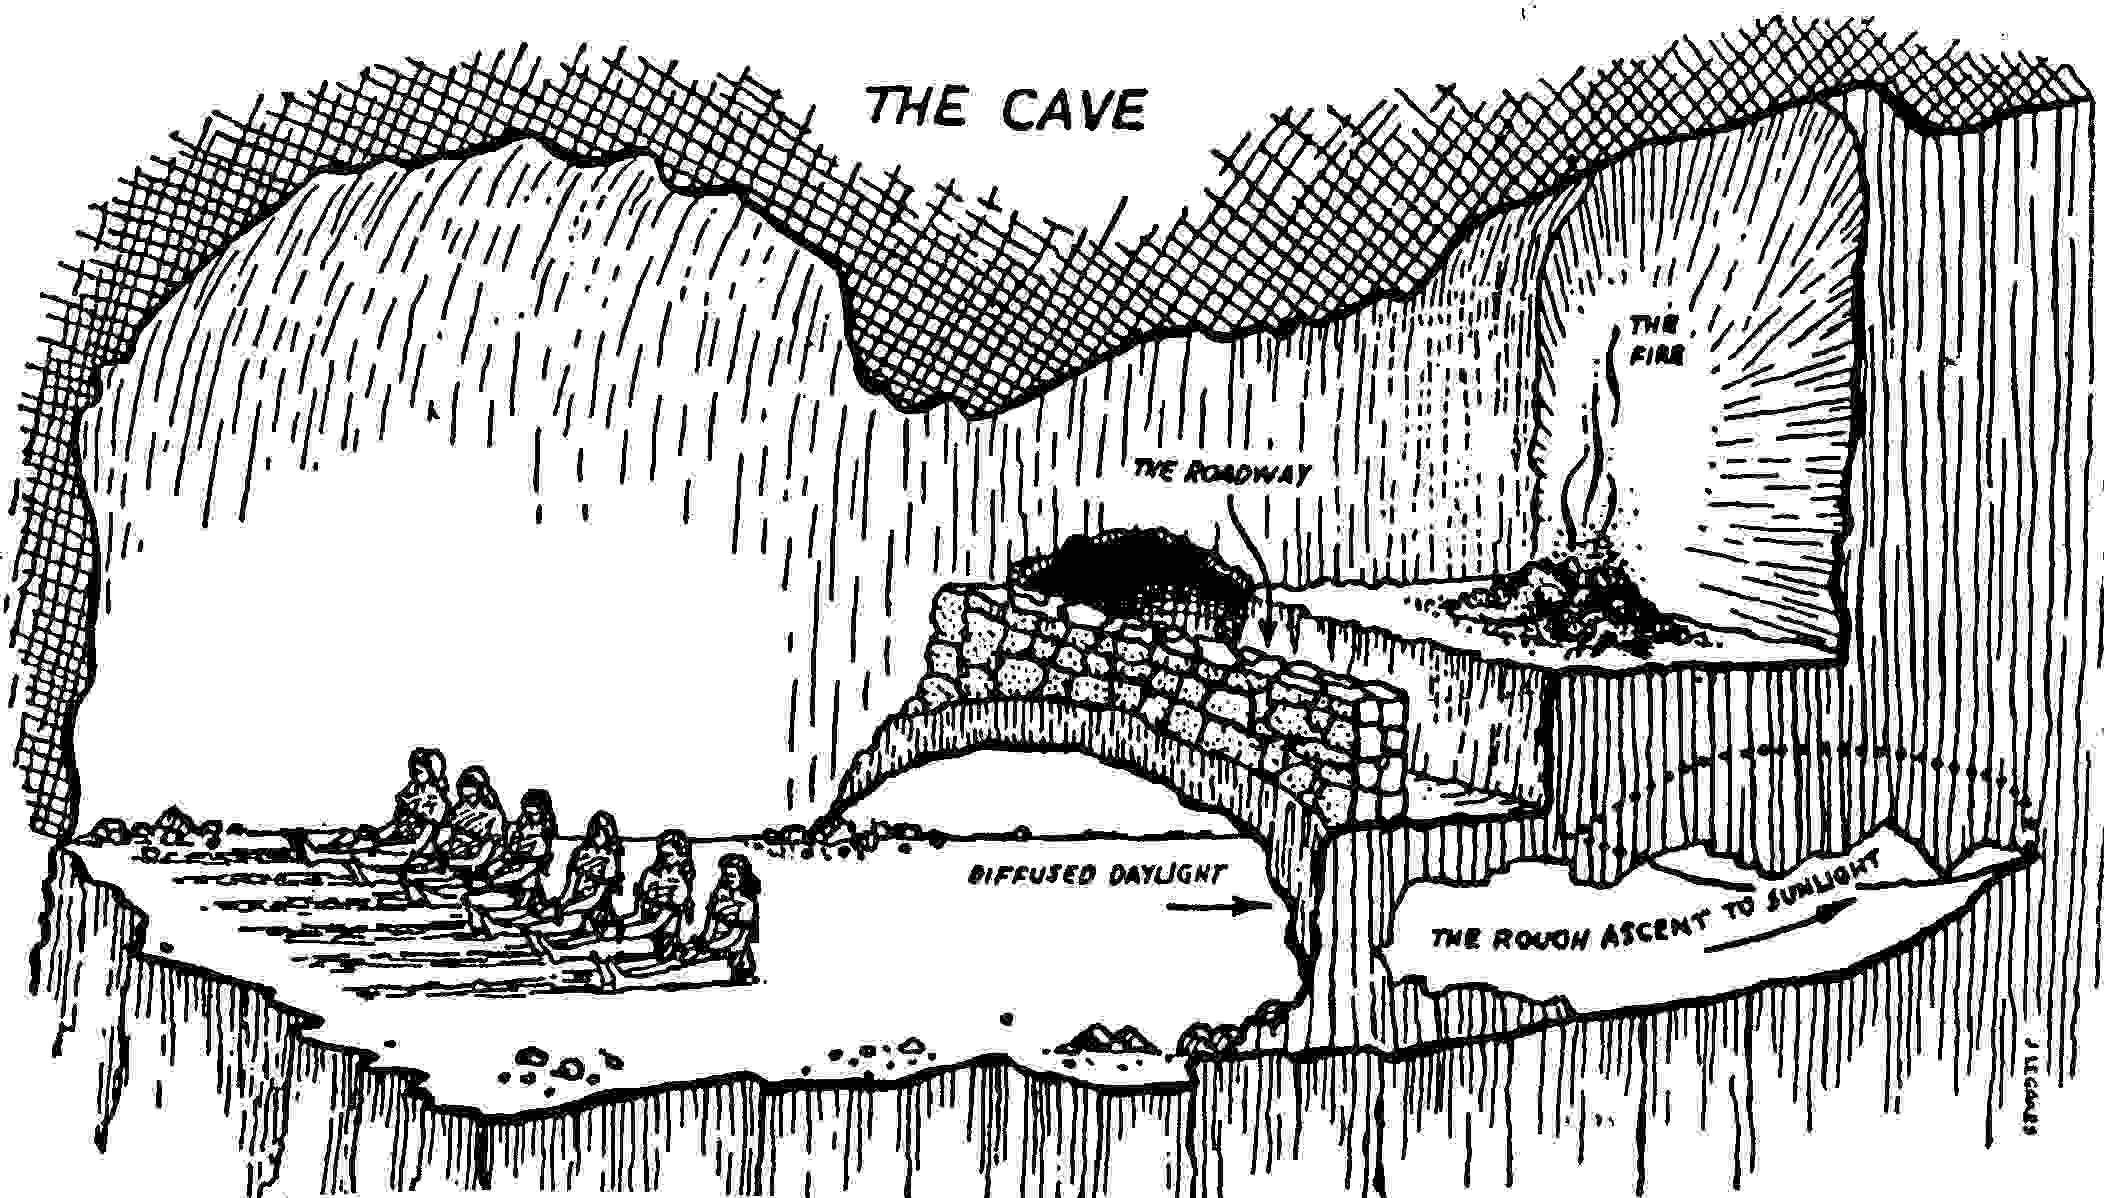

In [1]:
from IPython.display import Image
Image("plato.jpg")

Like the people in Plato's allegory for caves, we can perceive the observable data (x), but the data itself is generated by some random variable (z) a mean and variance. In variational autoencoders, we try to uncover these by 1. assuming it is standard normal distribution, we learn the mean and the log variance as part of the training outcome and use ELBO loss where we can control the reconstruction quality and distance between the learned distribution and the assumed noraml distribution

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import math
import random
from tqdm.notebook import tqdm as tqdm

In [3]:
# whether to compute on cpu or gpu
device="cpu" 
# device="cuda"

In [4]:
def frange_cycle_linear(start, stop, n_epoch, n_cycle=4, ratio=0.5):
    L = np.ones(n_epoch)
    period = n_epoch/n_cycle
    step = (stop-start)/(period*ratio) # linear schedule

    for c in range(n_cycle):

        v , i = start , 0
        while v <= stop and (int(i+c*period) < n_epoch):
            L[int(i+c*period)] = v
            v += step
            i += 1
    return L    

In [5]:
def frange_cycle_sigmoid(start, stop, n_epoch, n_cycle=4, ratio=0.5):
    L = np.ones(n_epoch)
    period = n_epoch/n_cycle
    step = (stop-start)/(period*ratio) # step is in [0,1]
    
    # transform into [-6, 6] for plots: v*12.-6.

    for c in range(n_cycle):

        v , i = start , 0
        while v <= stop:
            L[int(i+c*period)] = 1.0/(1.0+ np.exp(- (v*12.-6.)))
            v += step
            i += 1
    return L    


In [6]:
def frange_cycle_cosine(start, stop, n_epoch, n_cycle=4, ratio=0.5):
    L = np.ones(n_epoch)
    period = n_epoch/n_cycle
    step = (stop-start)/(period*ratio) # step is in [0,1]
    
    # transform into [0, pi] for plots: 

    for c in range(n_cycle):

        v , i = start , 0
        while v <= stop:
            L[int(i+c*period)] = 0.5-.5*math.cos(v*math.pi)
            v += step
            i += 1
    return L    


In [7]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [8]:
def sin(t):
    return np.sin(t)

def saw(t):
    return ( ((t-np.pi)/(2*np.pi))%1 - .5) *2

def square(t):
    return np.sign(np.sin(t))

def tri(t):
    sw = saw(t+np.pi/2)*2
    return sw * np.sign(sw)- 1

In [9]:
def create_waveforms(fn=sin, fs=512, duration=1024, period=440, phase=0, amplitude=1):
    period = np.array(period)
    period = np.reshape(period, (period.size, 1))

    phase = np.array(phase)
    phase = np.reshape(phase, (phase.size, 1))

    amplitude = np.array(amplitude)
    amplitude = np.reshape(amplitude, (amplitude.size, 1))

    t = (np.arange(0, duration, 1)/fs)[None,:]
    x = amplitude * fn(2*np.pi*(phase + t*period))
    return x, t

In [10]:
class VAE(torch.nn.Module):
    def __init__(self, input_dim=512, latent_dim=2, hidden_dims=[128, 64, 36]):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1],hidden_dims[2]),
            torch.nn.Tanh(),
            
        )

        self.z_mean = torch.nn.Linear(hidden_dims[2], latent_dim)
        self.z_log_var = torch.nn.Linear(hidden_dims[2], latent_dim)


        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dims[2]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1], hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], input_dim),
        )


    def reparameterize(self, z_mu, z_log_var):
        device = z_mu.device
        # Sampling the eps from the standard multivariate normal distribution in each forward pass
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device)
        # reparameterized_mean = mean_vector + random noise(eps) + log variance
        z = z_mu + eps * torch.exp(z_log_var / 2.0)
        return z

    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded,z_mean,z_log_var,decoded

In [11]:
input_length = 256

np.random.seed(0)
n_samples_train = 100000

periods_train = np.random.uniform(200, 2000, n_samples_train)

x_sin, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=periods_train[0*n_samples_train//4:1*n_samples_train//4], amplitude=1)
x_saw, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=periods_train[1*n_samples_train//4:2*n_samples_train//4], amplitude=1)
x_tri, _ = create_waveforms(fn=tri, fs=22050, duration=input_length, phase=0, period=periods_train[2*n_samples_train//4:3*n_samples_train//4], amplitude=1)
x_square, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=periods_train[3*n_samples_train//4:4*n_samples_train//4], amplitude=1)

x_train = torch.tensor(np.concatenate([x_sin, x_saw, x_tri, x_square], axis=0), dtype=torch.float32)
shapes_train = np.arange(n_samples_train) // (n_samples_train//4)


In [12]:
shuffle_indices = np.random.permutation(np.arange(n_samples_train))

x_train_shuffle = x_train[shuffle_indices]
shapes_train_shuffle = shapes_train[shuffle_indices]
periods_train_shuffle = periods_train[shuffle_indices]

In [13]:
x_train.shape

torch.Size([100000, 256])

In [14]:
autoencoder = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])

In [15]:
loss_function = torch.nn.MSELoss()

optim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode="min", factor=0.1, patience=3, threshold=1e-3, verbose=True)

In [16]:
dataset_train = torch.utils.data.TensorDataset(x_train, x_train)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=32, shuffle=True)

Epoch 0


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.5143


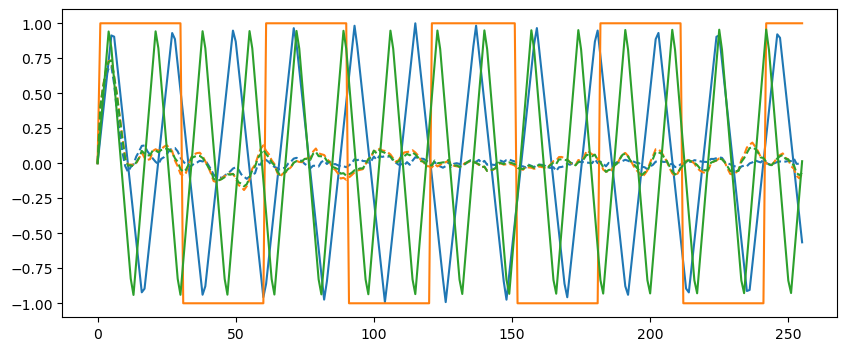

Epoch 1


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.5064
Epoch 2


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.4648
Epoch 3


...

loss: 0.4038
Epoch 4


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.3325
Epoch 5


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2751


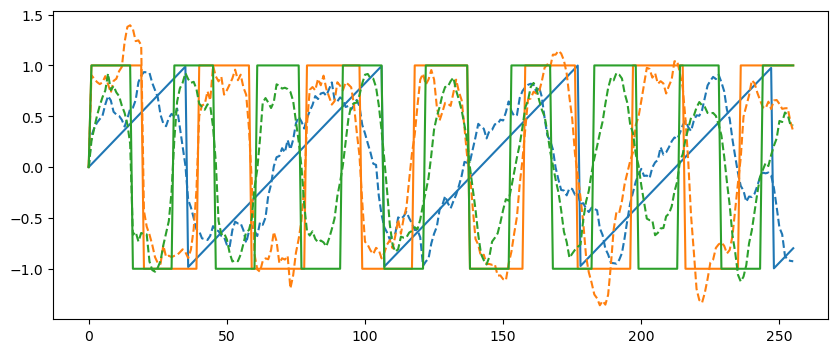

Epoch 6


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2446
Epoch 7


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2359
Epoch 8


...

loss: 0.2308
Epoch 9


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2273
Epoch 10


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2251


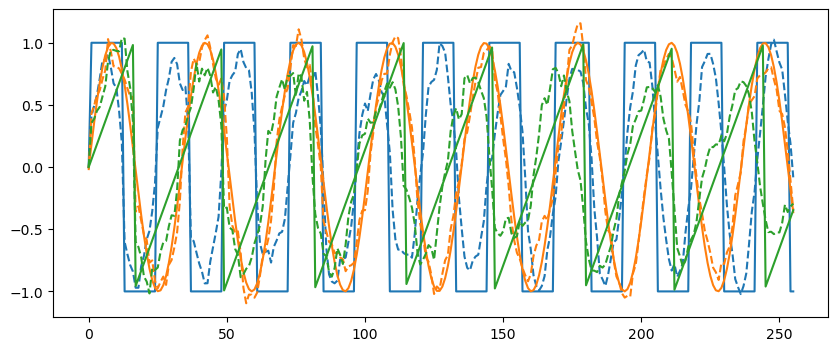

Epoch 11


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2242
Epoch 12


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2236
Epoch 13


...

loss: 0.2216
Epoch 14


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2215
Epoch 15


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2199


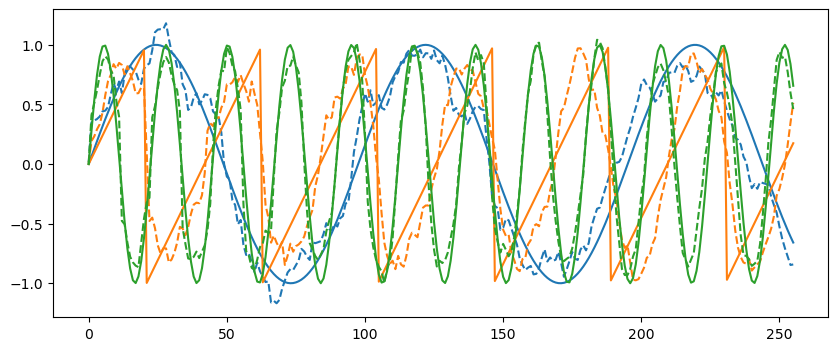

Epoch 16


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2189
Epoch 17


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2181
Epoch 18


...

loss: 0.2184
Epoch 19


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2170
Epoch 20


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2168


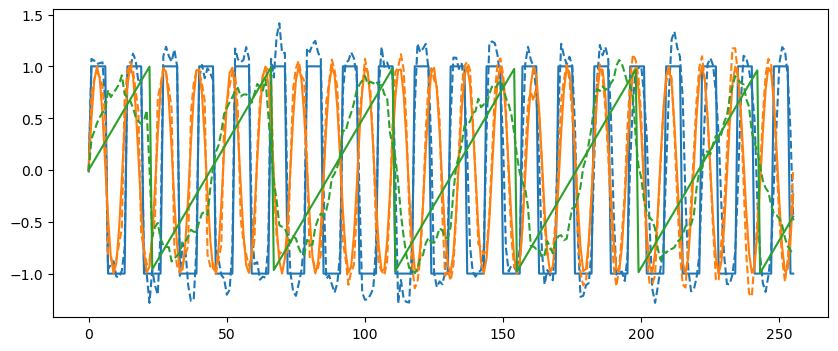

Epoch 21


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2161
Epoch 22


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2170
Epoch 23


...

loss: 0.2158
Epoch 24


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2152
Epoch 25


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2153


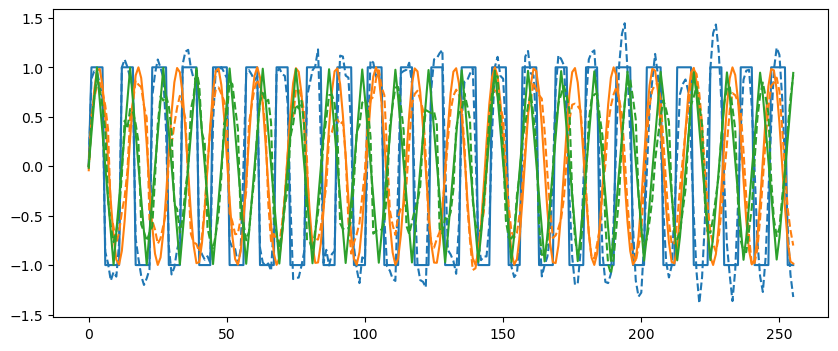

Epoch 26


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2158
Epoch 27


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2145
Epoch 28


...

loss: 0.2134
Epoch 29


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2127
Epoch 30


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2125


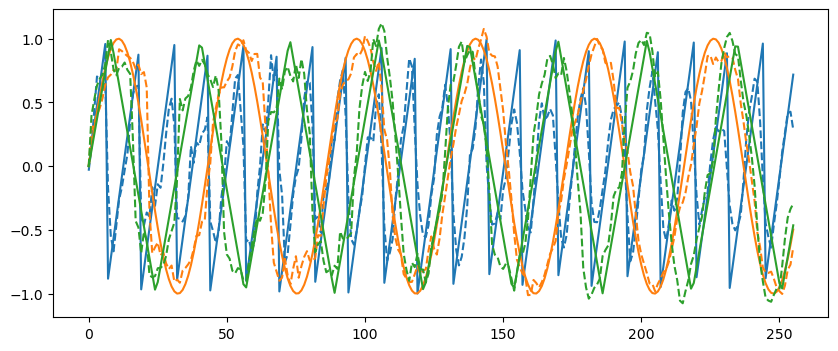

Epoch 31


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2120
Epoch 32


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2111
Epoch 33


...

loss: 0.2127
Epoch 34


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2113
Epoch 35


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2119


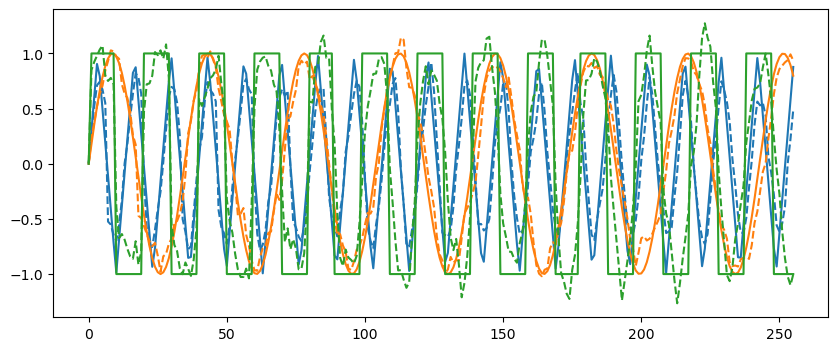

Epoch 36


  0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 00037: reducing learning rate of group 0 to 1.0000e-04.
loss: 0.2115
Epoch 37


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.2019
Epoch 38


...

loss: 0.2004
Epoch 39


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1998
Epoch 40


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1996


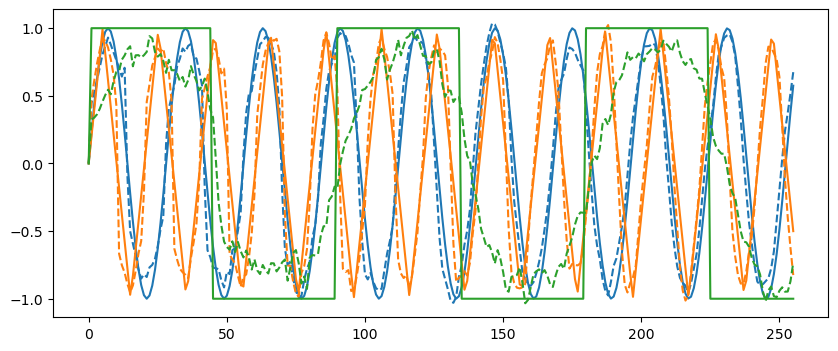

Epoch 41


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1992
Epoch 42


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1989
Epoch 43


...

loss: 0.1987
Epoch 44


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1987
Epoch 45


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1986


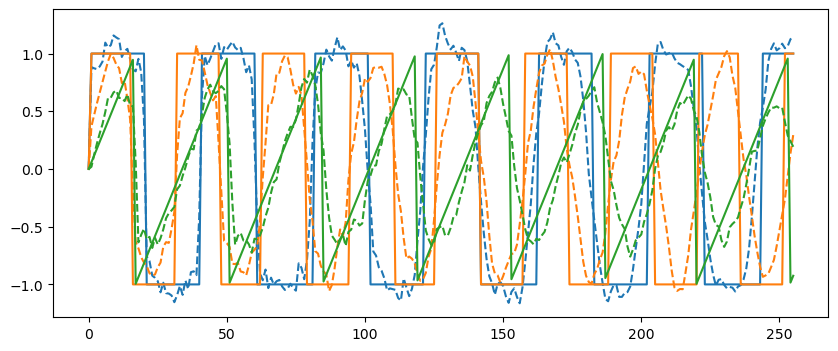

Epoch 46


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1983
Epoch 47


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1981
Epoch 48


...

loss: 0.1981
Epoch 49


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1980
Epoch 50


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1980


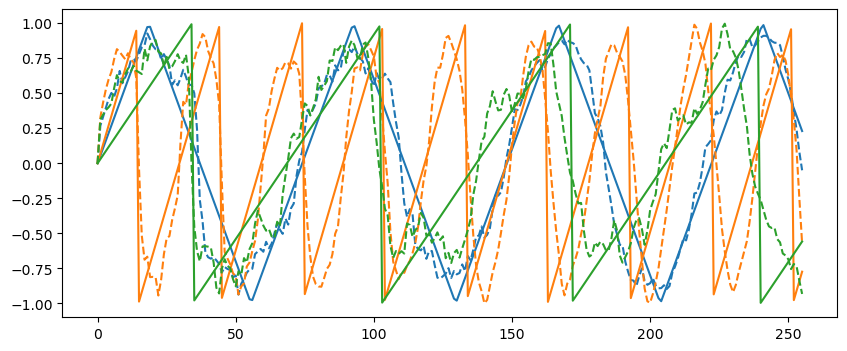

In [17]:
plot_freq=5
latent_dim = 2
random.seed(0)
# beta_schedule  = frange_cycle_cosine(start=0.01, stop=0.07, n_epoch=26, n_cycle=4, ratio=0.5)
beta = 0.0188
overall_loss = []
# beta_norm = (beta * 32)/10000
# print(beta_norm)
# beta = beta_norm
#todo : Normalize the KL Term and the reconstruction loss
#todo : Visualize the embedding spaces with different beta values
#todo : Experiment with different latent dimension
#todo : print the kl values for every dimension amidst training 
#todo :  Document all scenarios where the vae training collpases
#todo : experiment with the training data by creating imbalances in period and shapes 
#todo : know how to tell when there is good disentanglement
#todo : Acheieve good disentanglement your features

losses = []
kl_loss = []
reconstruction_loss = []
kl_div_per_dimension  = []
for epoch in range(51):
    losses_epoch = []
    kl_epoch = []
    reconstuction_epoch = []
    kl_epoch_per_dimension = []
    print("Epoch %i"%(epoch))
    for (data,_) in tqdm(dataloader_train):

        optim.zero_grad()
        encoded,z_mean,z_log_var,decoded = autoencoder(data)
        norm_x_squared = torch.norm(data.view(data.size(0), -1), p=2, dim=1)**2
        # kl_div = - 0.5 * torch.sum(1 + z_log_var
        #                            - z_mean ** 2
        #                            - torch.exp(z_log_var),
        #                            axis=1)
        # kl_div = kl_div.mean()
        kl_div_per_dim = -0.5 * (1 + z_log_var - z_mean ** 2 - torch.exp(z_log_var))
        kl_div_mean_per_dim = kl_div_per_dim.mean(axis=0)
        kl_div = (kl_div_per_dim.sum(axis=1).mean())
        # kl_div = kl_div/latent_dim
       
        recon_loss = loss_function(decoded, data)
        # energy_norm = torch.norm(data, p=2, dim=1).mean()
        # recon_loss = recon_loss/(energy_norm ** 2)

        loss =  (1-beta) * recon_loss + beta * kl_div
      
        loss.backward()
        optim.step()
        losses_epoch.append(loss.detach().numpy())
        kl_epoch.append(kl_div.detach().numpy())
        reconstuction_epoch.append(recon_loss.detach().numpy())
        kl_epoch_per_dimension.append(kl_div_mean_per_dim.detach().numpy())
    scheduler.step(np.mean(losses_epoch))
    kl_loss.append(np.mean(kl_epoch))
    losses.append(np.mean(losses_epoch))
    reconstruction_loss.append(np.mean(reconstuction_epoch))
    kl_div_per_dimension.append(np.mean(kl_epoch_per_dimension, axis=0))
    print("loss: %.4f"%(losses[-1]))

    if epoch%plot_freq == 0:
        plt.figure(figsize=(10,4))
        plt.plot(data[0].detach().numpy(), color='tab:blue', linestyle='-')
        plt.plot(decoded[0].detach().numpy(), color='tab:blue', linestyle='--')
    
        plt.plot(data[1].detach().numpy(), color='tab:orange', linestyle='-')
        plt.plot(decoded[1].detach().numpy(), color='tab:orange', linestyle='--')
    
        plt.plot(data[2].detach().numpy(), color='tab:green', linestyle='-')
        plt.plot(decoded[2].detach().numpy(), color='tab:green', linestyle='--')    
        plt.show()
        

In [18]:
x = autoencoder.encoder(x_train_shuffle)
z_mean, z_log_var = autoencoder.z_mean(x), autoencoder.z_log_var(x)
encoded = autoencoder.reparameterize(z_mean, z_log_var).detach().numpy()

In [19]:
encoded.shape

(100000, 2)

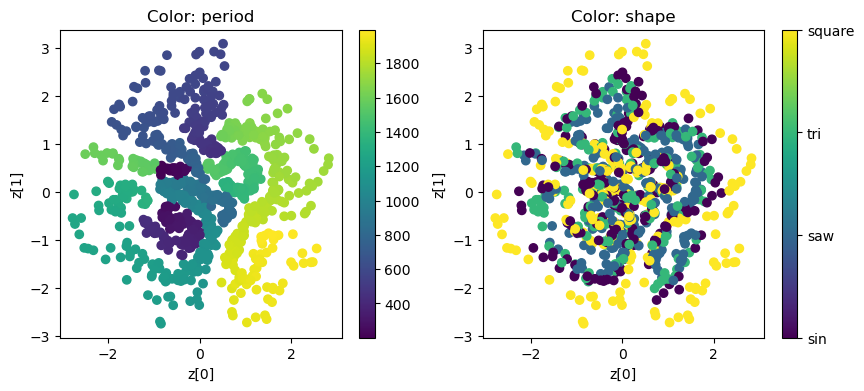

In [20]:
n_plot=1000

fig, ax = plt.subplots(1,2, figsize=(10,4))

im0 = ax[0].scatter(encoded[:n_plot,0], encoded[:n_plot,1], c=periods_train_shuffle[:n_plot])
im1 = ax[1].scatter(encoded[:n_plot,0], encoded[:n_plot,1], c=shapes_train_shuffle[:n_plot])

ax[0].set_xlabel("z[0]")
ax[0].set_ylabel("z[1]")
ax[0].set_title("Color: period")

ax[1].set_xlabel("z[0]")
ax[1].set_ylabel("z[1]")
ax[1].set_title("Color: shape")

plt.colorbar(im0, ax=ax[0])
cbar = plt.colorbar(im1, ax=ax[1], ticks=[0, 1, 2, 3])

cbar.ax.set_yticklabels(["sin", "saw", "tri", "square"])

plt.show()

In [21]:
torch.save(autoencoder.state_dict(), 'beta_zeroeightfive.pth')

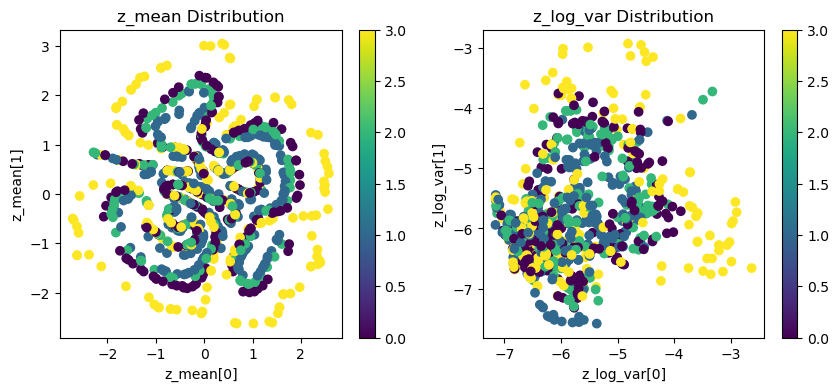

In [22]:
n_plot = 1000

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(z_mean[:n_plot, 0].detach().numpy(), z_mean[:n_plot, 1].detach().numpy(), c=shapes_train_shuffle[:n_plot])
plt.xlabel("z_mean[0]")
plt.ylabel("z_mean[1]")
plt.title("z_mean Distribution")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(z_log_var[:n_plot, 0].detach().numpy(), z_log_var[:n_plot, 1].detach().numpy(), c=shapes_train_shuffle[:n_plot])
plt.xlabel("z_log_var[0]")
plt.ylabel("z_log_var[1]")
plt.title("z_log_var Distribution")
plt.colorbar()

plt.show()

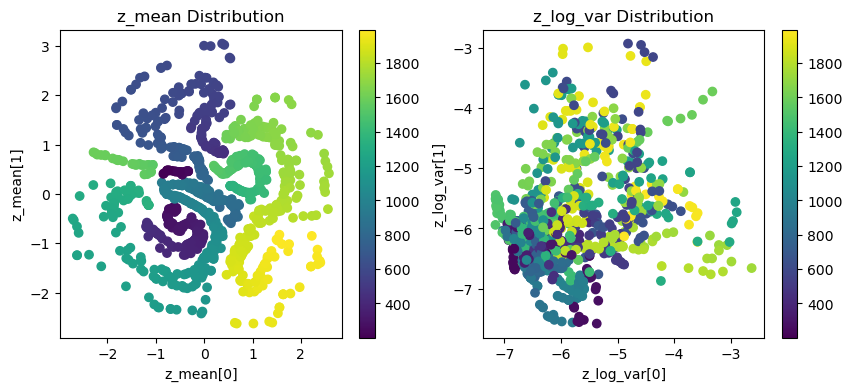

In [23]:
n_plot = 1000

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(z_mean[:n_plot, 0].detach().numpy(), z_mean[:n_plot, 1].detach().numpy(), c=periods_train_shuffle[:n_plot])
plt.xlabel("z_mean[0]")
plt.ylabel("z_mean[1]")
plt.title("z_mean Distribution")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(z_log_var[:n_plot, 0].detach().numpy(), z_log_var[:n_plot, 1].detach().numpy(), c=periods_train_shuffle[:n_plot])
plt.xlabel("z_log_var[0]")
plt.ylabel("z_log_var[1]")
plt.title("z_log_var Distribution")
plt.colorbar()

plt.show()

### Interpolate in the embedding space and decode


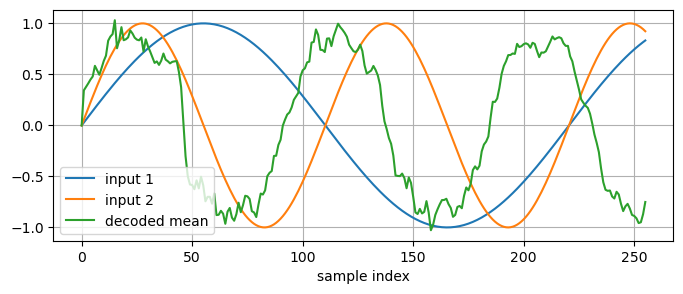

In [24]:
x1, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=100, amplitude=1)
x2, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=200, amplitude=1)

z1 = autoencoder.encoder(torch.Tensor(x1))
z2 = autoencoder.encoder(torch.Tensor(x2))

zMean = (0.3*z1+0.7*z2)
z_mean, z_log_var = autoencoder.z_mean(zMean), autoencoder.z_log_var(zMean)
encoded = autoencoder.reparameterize(z_mean, z_log_var)
yMean = autoencoder.decoder(encoded)
plt.figure(figsize=(8,3))
plt.plot(x1[0], label='input 1')
plt.plot(x2[0], label='input 2')
plt.plot(yMean[0].detach().numpy(), label='decoded mean')
plt.grid()
plt.xlabel("sample index")
plt.legend()
plt.show()

In [25]:
def reconstruction_error(original, reconstruction):
    return np.mean((original - reconstruction)**2)

In [26]:
true_mean = (0.3*x1[0] + 0.7*x2[0])

In [27]:
reconstruction_error(true_mean,yMean[0].detach().numpy())

0.7341207065988102

In [28]:
def psnr(original, reconstruction, max_val=1.0):
    mse = np.mean((original - reconstruction) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(max_val / np.sqrt(mse))

In [29]:
psnr(true_mean,yMean[0].detach().numpy())

1.3423252605145233

## Questions

1. How do I know which beta to select?
2. How exactly does beta vae encourage disengagement ?
3. List down all the requirements to progress into music 

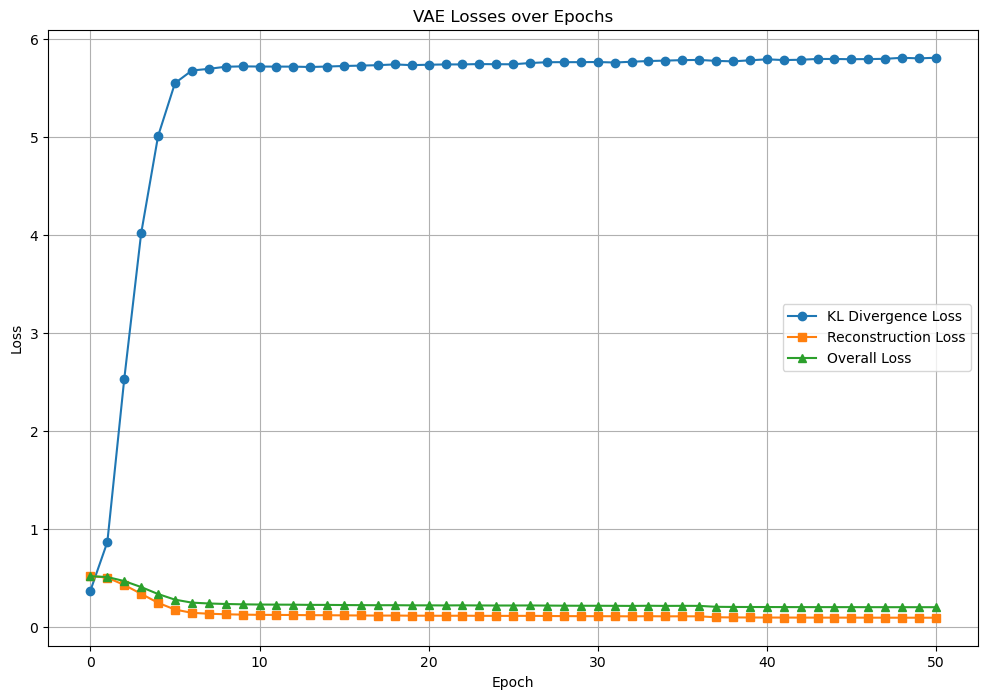

In [30]:
kl_loss_values = [kl.item() for kl in kl_loss]
reconstruction_loss_values = [reconst.item() for reconst in reconstruction_loss]
overall_loss_values = [overall.item() for overall in losses]
plt.figure(figsize=(12, 8))
plt.plot(kl_loss_values, marker='o', linestyle='-', label='KL Divergence Loss')
plt.plot(reconstruction_loss_values, marker='s', linestyle='-', label='Reconstruction Loss')
plt.plot(overall_loss_values, marker='^', linestyle='-', label='Overall Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Losses over Epochs')
plt.legend()
plt.grid(True)
plt.show()

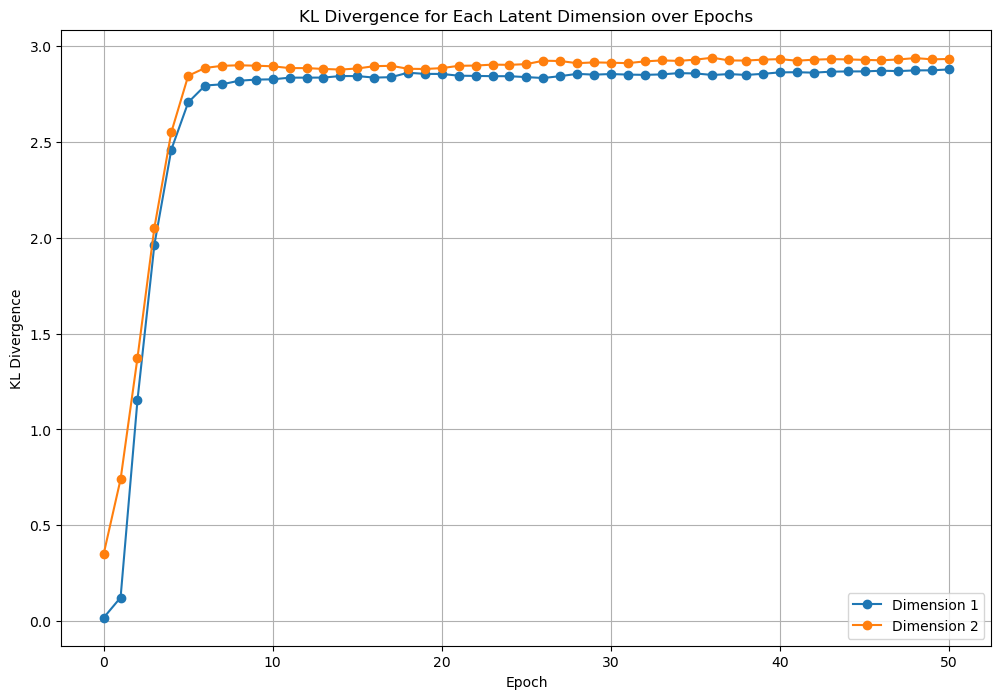

In [31]:
plt.figure(figsize=(12, 8))
for i in range(len(kl_div_per_dimension[0])):
    plt.plot([epoch[i] for epoch in kl_div_per_dimension], marker='o', linestyle='-', label=f'Dimension {i+1}')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.title('KL Divergence for Each Latent Dimension over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
torch.mean(x_train)

tensor(0.0169)

In [33]:
torch.mean(yMean)

tensor(0.0520, grad_fn=<MeanBackward0>)

In [34]:
x1.shape

(1, 256)

In [35]:
mean = 0 
std_dev = 1  
num_samples = 15  
samples = [np.random.normal(mean, std_dev, (1, 256)) for _ in range(num_samples)]

In [36]:
random_sample = autoencoder.encoder(torch.Tensor(samples[0]))

In [37]:
z_mean, z_log_var = autoencoder.z_mean(z1), autoencoder.z_log_var(random_sample)
encoded_exp = autoencoder.reparameterize(z_mean, z_log_var)
test = autoencoder.decoder(encoded_exp)

In [38]:
torch.mean(test)

tensor(0.0106, grad_fn=<MeanBackward0>)

In [39]:
target_mean = torch.tensor(0.0569)
for i, sample in enumerate(samples):
    random_sample = autoencoder.encoder(torch.Tensor(sample))
    z_mean = autoencoder.z_mean(random_sample)
    z_log_var = autoencoder.z_log_var(random_sample)
    encoded_exp = autoencoder.reparameterize(z_mean, z_log_var)
    decoded_sample = autoencoder.decoder(encoded_exp)
    mean_decoded_sample = torch.mean(decoded_sample)
    is_mean_close = torch.allclose(mean_decoded_sample, target_mean, atol=1e-4)
    if is_mean_close is False:
        print("mean is not 0.0572")

mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572
mean is not 0.0572


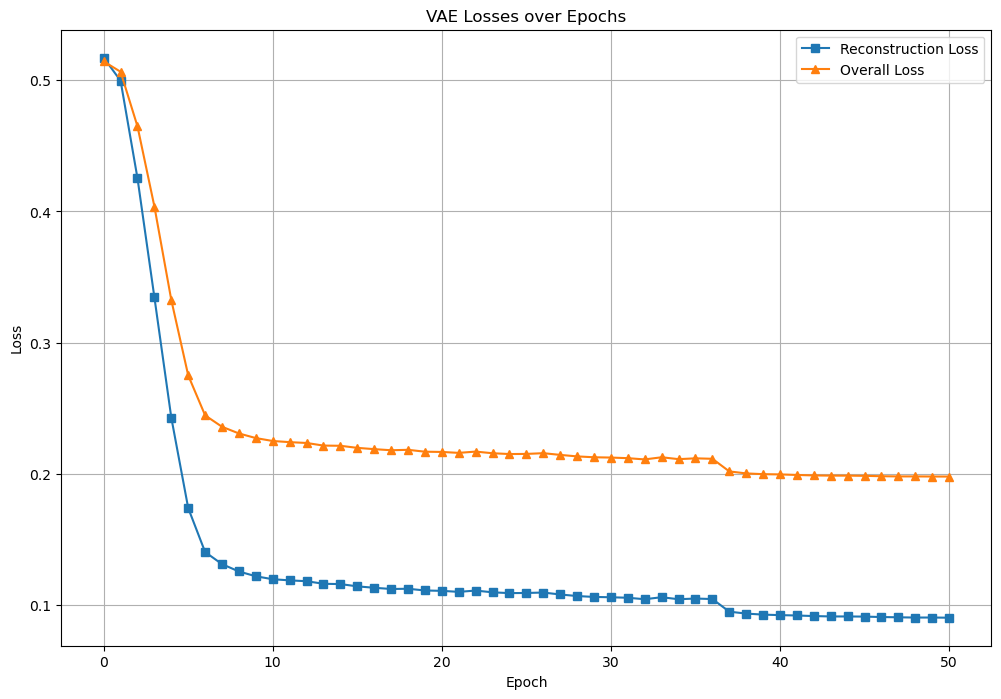

In [40]:
kl_loss_values = [kl.item() for kl in kl_loss]
reconstruction_loss_values = [reconst.item() for reconst in reconstruction_loss]
overall_loss_values = [overall.item() for overall in losses]
plt.figure(figsize=(12, 8))
# plt.plot(kl_loss_values, marker='o', linestyle='-', label='KL Divergence Loss')
plt.plot(reconstruction_loss_values, marker='s', linestyle='-', label='Reconstruction Loss')
plt.plot(overall_loss_values, marker='^', linestyle='-', label='Overall Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Losses over Epochs')
plt.legend()
plt.grid(True)
plt.show()